# Frequency Perturbation

`frequency_perturbation` takes an rFFT, adds complex noise to a random subset of
bins, and inverts. `r` is the **fraction of bins** that are touched.
`min_alpha` / `max_alpha` bound the absolute size of the real and imaginary
offsets (sampled in $[-\alpha_{\max},-\alpha_{\min}]\cup[\alpha_{\min},\alpha_{\max}]$).

There are **no defaults** for `min_alpha` and `max_alpha`; they must be set.

| Parameter | Default | Role |
| --- | --- | --- |
| `min_alpha` | (required) | Smallest |perturbation| |
| `max_alpha` | (required) | Largest |perturbation| |
| `r` | 0.5 | Fraction of frequency bins to perturb |
| `rng` | None | Used for the perturbation amplitudes |


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import frequency_perturbation

sine = np.sin(2 * np.pi * np.arange(L) / 32.0) + 0.05 * rng.normal(size=L)

## Default-ish effect (`r=0.5`, modest alpha) on sine and real series


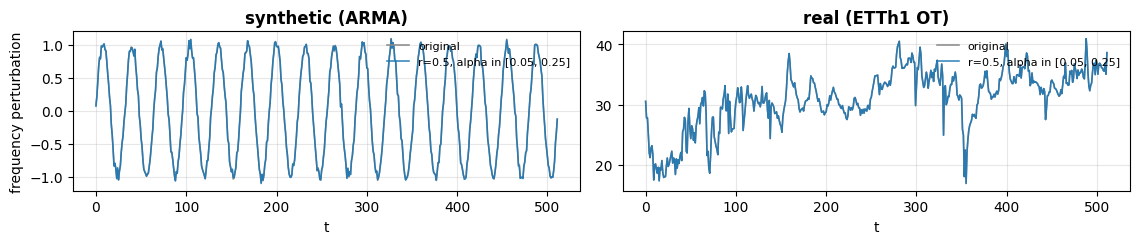

In [2]:
aug_s = frequency_perturbation(
    sine, min_alpha=0.05, max_alpha=0.25, r=0.5, rng=np.random.RandomState(1)
)
aug_r = frequency_perturbation(
    real, min_alpha=0.05, max_alpha=0.25, r=0.5, rng=np.random.RandomState(1)
)
overlay_pair(
    [sine, real],
    [
        [("r=0.5, alpha in [0.05, 0.25]", aug_s)],
        [("r=0.5, alpha in [0.05, 0.25]", aug_r)],
    ],
    titles=["frequency perturbation"],
)
plt.show()

## Parameter effect

Small `r` and small `alpha` keep the waveform almost intact. Large `alpha` at
the same `r` injects broadband noise and can bury the original oscillation.
(The implementation perturbs rFFT bins, so `r` is safest in `[0, 0.5]` for typical even lengths.)


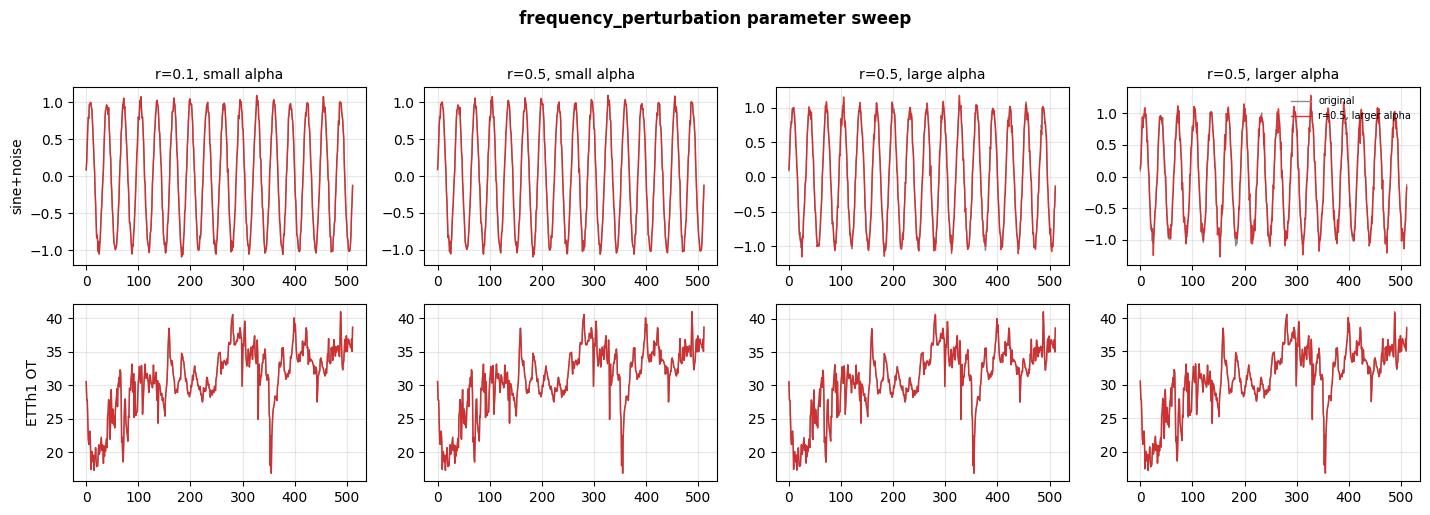

In [3]:
makers = [
    (
        "r=0.1, small alpha",
        lambda x: frequency_perturbation(
            x, 0.02, 0.08, r=0.1, rng=np.random.RandomState(5)
        ),
    ),
    (
        "r=0.5, small alpha",
        lambda x: frequency_perturbation(
            x, 0.02, 0.08, r=0.5, rng=np.random.RandomState(5)
        ),
    ),
    (
        "r=0.5, large alpha",
        lambda x: frequency_perturbation(
            x, 0.3, 1.2, r=0.5, rng=np.random.RandomState(5)
        ),
    ),
    (
        "r=0.5, larger alpha",
        lambda x: frequency_perturbation(
            x, 0.8, 2.0, r=0.5, rng=np.random.RandomState(5)
        ),
    ),
]
sweep_grid(
    [sine, real],
    ["sine+noise", "ETTh1 OT"],
    makers,
    "frequency_perturbation parameter sweep",
)
plt.show()